Importing Libraries and Load The Data

In [36]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("california_housing.csv")
print(f"loaded: {df.shape[0]} California districts, {df.shape[1]} columns")
df.head()
 


loaded: 5000 California districts, 9 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634


TASK 01 Split and scale

• Separate features (X) from the target (y = MedHouseVal).

In [4]:
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]
print(f"X: {X.shape} features, y: {y.shape} target values")

X: (5000, 8) features, y: (5000,) target values


• Split into training and test sets (80/20), with a fixed random_state so it's reproducible

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"\ntraining on {len(X_train)} districts, testing on {len(X_test)}")


training on 4000 districts, testing on 1000


• Standardize the features: fit the scaler on the TRAINING data only, then transform both train and test.

• Confirm the scaled training features have roughly mean 0 and spread 1.

• Explain in one sentence why you must not fit the scaler using the test data.

In [8]:
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("after scaling, each feature has ~0 mean and ~1 spread:")
print(f"  training mean: {X_train_scaled.mean():.3f}, std: {X_train_scaled.std():.3f}")

#it would cause data leakage, allowing the model to indirectly see information from the test set before evaluation.

after scaling, each feature has ~0 mean and ~1 spread:
  training mean: -0.000, std: 1.000


In [ ]:
x_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
x_train_scaled_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.833989,-1.039720,1.566882,-0.546410,-0.522086,-0.442791,-1.251524,0.378613
1,1.385364,-0.630247,1.474037,-0.574813,0.798249,0.693444,-0.559865,0.584550
2,-0.545230,0.393435,-0.533372,-0.019607,-0.252340,-0.536022,-1.319969,-0.015810
3,0.462918,0.393435,-1.385996,1.071870,-0.533241,-0.273026,0.405575,0.940578
4,0.653185,1.280627,1.041447,-0.544381,-0.643776,1.832588,0.012915,-0.972198


TASK 02 Method 1 — the closed-form solution

• Add a bias column (a column of 1s) to your scaled feature matrix.

In [11]:
def add_bias(X_matrix):
    return np.c_[np.ones(len(X_matrix)), X_matrix]

X_train_b = add_bias(X_train_scaled)

X_test_b = add_bias(X_test_scaled)

print(f"added bias column: X now has shape {X_train_b.shape}")


added bias column: X now has shape (4000, 9)


In [15]:
# MSE function 

def mse(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)

Implement the normal equations directly: w = (X^T X)^-1 X^T y, using numpy.

• Print the learned weights (the bias and the feature weights).

• Use the weights to predict on the test set, and compute the test MSE.

In [16]:

w_closed = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train.values

print("weights from the closed-form solution:")
print(f"  bias (w0):     {w_closed[0]:.4f}")
print(f"  first 3 feature weights: {w_closed[1:4].round(4)}")

# evaluate on the test set
pred_closed = X_test_b @ w_closed
print(f"\ntest MSE: {mse(y_test.values, pred_closed):.4f}")

weights from the closed-form solution:
  bias (w0):     2.2095
  first 3 feature weights: [0.8799 0.1696 0.034 ]

test MSE: 0.1648


TASK 03 Method 2 — gradient descent

• Implement gradient descent from scratch: start with zero weights, then loop, each step computing the gradient of
MSE and nudging the weights downhill.


In [26]:
w_gd = np.zeros(X_train_b.shape[1])   # start at all zeros
learning_rate = 0.1
n = len(y_train)
history = []

for step in range(2000):
    predictions = X_train_b @ w_gd
    errors = predictions - y_train.values
    # the gradient of MSE with respect to the weights
    gradient = (2 / n) * X_train_b.T @ errors
    w_gd -= learning_rate * gradient           # step downhill
    history.append(mse(y_train.values, predictions))

print("weights from gradient descent:")
print(f"  bias (w0):     {w_gd[0]:.4f}")
print(f"  first 3 feature weights: {w_gd[1:4].round(4)}")

weights from gradient descent:
  bias (w0):     2.2095
  first 3 feature weights: [0.8799 0.1696 0.034 ]



• Store the training loss at each step, and plot it — you should see it fall and flatten.

• Print the final weights.

• Tune the learning rate and number of steps until the loss clearly converges.



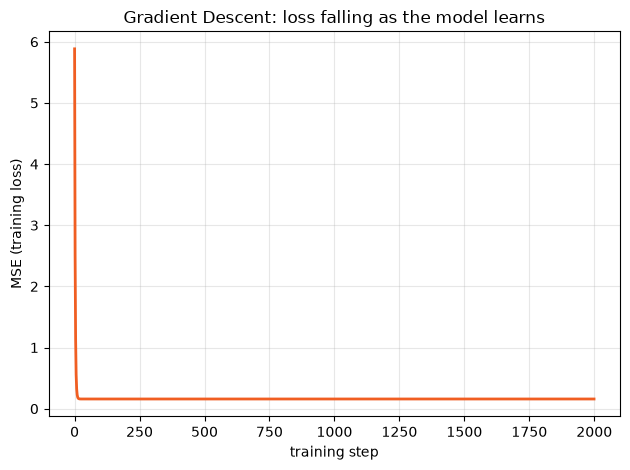

loss started at 5.885 and fell to 0.1588


In [27]:
fig, ax = plt.subplots()
ax.plot(history, color="#F05E22", linewidth=2)
ax.set_title("Gradient Descent: loss falling as the model learns")
ax.set_xlabel("training step"); ax.set_ylabel("MSE (training loss)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"loss started at {history[0]:.3f} and fell to {history[-1]:.4f}")


• Compare your gradient-descent weights to your closed-form weights. Do they match?

In [29]:
print(f"  closed-form first 3: {w_closed[:3].round(4)}")
print(f"  grad-descent first 3: {w_gd[:3].round(4)}")
print(f"\nmatch (within rounding)? {np.allclose(w_closed, w_gd, atol=1e-3)}")

  closed-form first 3: [2.2095 0.8799 0.1696]
  grad-descent first 3: [2.2095 0.8799 0.1696]

match (within rounding)? True


TASK 04 Method 3 — sklearn, and prove all three match

• Fit an sklearn LinearRegression on the same scaled training data.

• Print its intercept and coefficients.

In [32]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)          # learn the weights
pred_sklearn = model.predict(X_test_scaled) # predict on the test set

sklearn_w = np.r_[model.intercept_, model.coef_]

print("weights from sklearn:")
print(f"  bias (intercept): {model.intercept_:.4f}")
print(f"  first 3 feature weights: {model.coef_[:3].round(4)}")

weights from sklearn:
  bias (intercept): 2.2095
  first 3 feature weights: [0.8799 0.1696 0.034 ]


• Put all three sets of weights side by side (closed-form, gradient descent, sklearn).

In [ ]:
print("all three methods, bias + first 2 weights:")
print(f"  closed-form:  {w_closed[:3].round(4)}")
print(f"  grad-descent: {w_gd[:3].round(4)}")
print(f"  sklearn:      {sklearn_w[:3].round(4)}")


all three methods, bias + first 2 weights:
  closed-form:  [2.2095 0.8799 0.1696]
  grad-descent: [2.2095 0.8799 0.1696]
  sklearn:      [2.2095 0.8799 0.1696]

closed-form == sklearn? True


• Show numerically that all three agree (within small rounding differences). This match is the heart of the
deliverable.

• Write one sentence on what this proves about what sklearn is doing 'under the hood'.

In [35]:

print(f"\nclosed-form == sklearn? {np.allclose(w_closed, sklearn_w, atol=1e-6)}")

#scikit-learn is using the same underlying mathematics to find the best weights, but implements it efficiently and professionally under the hood


closed-form == sklearn? True


TASK 05 Evaluate with four metrics

• On the test set, compute MSE, RMSE, MAE, and R².

In [38]:
mse_val = mean_squared_error(y_test, pred_sklearn)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_test, pred_sklearn)
r2_val = r2_score(y_test, pred_sklearn)

print(f" MSE:  {mse_val:.4f}")
print(f" RMSE:  {rmse_val:.4f}")
print(f" MAE:  {mae_val:.4f}")
print(f" R2:  {r2_val:.4f}")



 MSE:  0.1648
 RMSE:  0.4059
 MAE:  0.3193
 R2:  0.8383


• Convert RMSE and MAE into real dollars (the target is in $100,000s) and state the typical error.

In [39]:
print("how good is our model? (target is in $100,000s)")

print(f"  RMSE: {rmse_val:.4f}   -> typical error ~${rmse_val*100000:,.0f}")
print(f"  MAE:  {mae_val:.4f}   -> average error ~${mae_val*100000:,.0f}")


how good is our model? (target is in $100,000s)
  RMSE: 0.4059   -> typical error ~$40,592
  MAE:  0.3193   -> average error ~$31,932


• Interpret R² in one plain sentence: what fraction of the variation does the model explain?

In [40]:
print(f"  R2:   {r2_val:.4f}   -> explains {r2_val*100:.0f}% of the variation in price")

  R2:   0.8383   -> explains 84% of the variation in price


• Make a predicted-vs-actual scatter plot, with a diagonal line showing where perfect predictions would fall

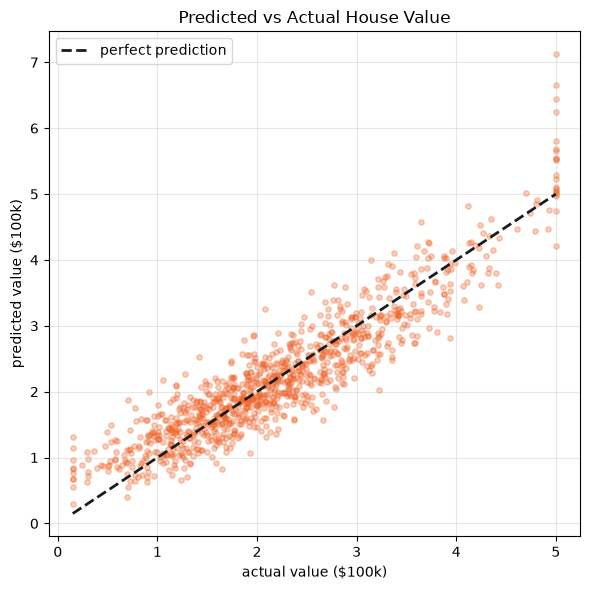

In [41]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_sklearn, alpha=0.3, color="#F05E22", s=15)
# a perfect model would put every point on this diagonal line
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, color="#1A1D1D", linewidth=2, linestyle="--", label="perfect prediction")
ax.set_title("Predicted vs Actual House Value")
ax.set_xlabel("actual value ($100k)"); ax.set_ylabel("predicted value ($100k)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

• Looking at that plot, describe where the model does well and where it struggles

In [42]:
# Model works well at median values but at the lower piont and higher point it gets the large error 


TASK 06 Interpret the coefficients (the other deliverable)

• List the feature weights, sorted by absolute size (biggest effect first). Because the features are scaled, they're
directly comparable.

In [43]:
coefs = pd.DataFrame({
    "feature": X.columns,
    "weight": model.coef_,
}).sort_values("weight", key=abs, ascending=False)

print("what the model learned (features ranked by importance):")
print(coefs.to_string(index=False))

what the model learned (features ranked by importance):
   feature    weight
    MedInc  0.879916
 Longitude -0.170009
  HouseAge  0.169620
  Latitude -0.149141
  AveOccup -0.112161
  AveRooms  0.033981
Population -0.002174
 AveBedrms  0.001896


• Make a horizontal bar chart of the weights, with a clear zero line and colour showing positive vs negative.

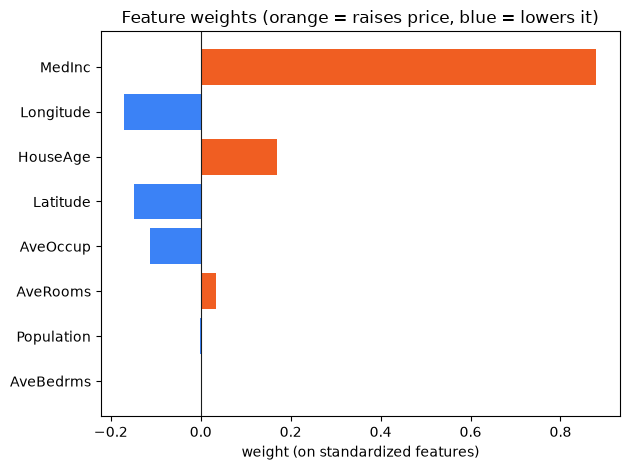

In [44]:
fig, ax = plt.subplots()
colors = ["#F05E22" if w > 0 else "#3B82F6" for w in coefs["weight"]]
ax.barh(coefs["feature"], coefs["weight"], color=colors)
ax.axvline(0, color="#1A1D1D", linewidth=0.8)
ax.set_title("Feature weights (orange = raises price, blue = lowers it)")
ax.set_xlabel("weight (on standardized features)")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

• Write a plain-English interpretation: which feature drives price most? Which push it up, which push it down?

In [45]:
#The MedInc (median income) feature drives the price most. Higher income and some location factors push the price up, while AveOccup pushes it down.

• Identify any features whose weight is near zero — what does that mean?

In [47]:
#Features with near-zero weights have very little effect on the prediction after considering the other features. For example, AveBedrms has a near-zero weight.

• Explain in two sentences why interpretability like this is valuable, and why some 'better' models lack it.

In [48]:
#Interpretability helps us understand why the model makes a prediction and which features are important. Some more complex models may be more accurate, but they are harder to understand and explain.